In [1]:
import pandas as pd
import numpy as np

# Configuração da aleatoriedade
np.random.seed(42)

# Número de registros
n_samples = 500

# Gerando dados fictícios para vinhos
wine_id = np.arange(1, n_samples + 1)
wine_type = np.random.choice(['Red', 'White'], size=n_samples, p=[0.4, 0.6])  # alvo da classificação
acidity = np.round(np.random.normal(loc=7.0, scale=0.8, size=n_samples), 2)   # acidez média
alcohol = np.round(np.random.normal(loc=12.0, scale=1.5, size=n_samples), 2)  # teor alcoólico
sugar = np.round(np.random.normal(loc=5.0, scale=2.0, size=n_samples), 2)     # açúcar residual
pH = np.round(np.random.normal(loc=3.3, scale=0.2, size=n_samples), 2)        # pH
quality = np.random.randint(3, 9, size=n_samples)                             # nota de qualidade (3 a 8)
origin = np.random.choice(['France', 'Italy', 'Spain', 'USA', 'Chile', 'Brazil'], size=n_samples)

# Criando DataFrame
df_wines = pd.DataFrame({
    'Wine_ID': wine_id,
    'Type': wine_type,
    'Acidity': acidity,
    'Alcohol': alcohol,
    'Residual_Sugar': sugar,
    'pH': pH,
    'Quality': quality,
    'Origin': origin
})

# Salvando em CSV
df_wines.to_csv("wine_dataset.csv", index=False)
print("Arquivo 'wine_dataset.csv' criado com sucesso!")


Arquivo 'wine_dataset.csv' criado com sucesso!


In [2]:
# Célula 1 - Imports e configurações
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from scipy import stats

# Configurações visuais
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)
RANDOM_STATE = 42


In [3]:
# Célula 2 - Carregar e inspecionar os dados
df = pd.read_csv("wine_dataset.csv")
print("Dimensão do dataset:", df.shape)
display(df.head())
print("\nInformações gerais:")
display(df.info())
print("\nEstatísticas descritivas:")
display(df.describe(include='all'))


Dimensão do dataset: (500, 8)


,Wine_ID,Type,Acidity,Alcohol,Residual_Sugar,pH,Quality,Origin
0,1,Red,7.27,12.88,7.60,3.14,3,Brazil
1,2,White,8.50,11.46,8.12,3.38,4,Spain
2,3,White,7.76,12.89,5.06,3.21,8,Brazil
3,4,White,6.54,13.66,3.49,3.30,4,Chile
4,5,Red,6.28,13.23,5.92,3.41,7,France



Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Wine_ID         500 non-null    int64  
 1   Type            500 non-null    object 
 2   Acidity         500 non-null    float64
 3   Alcohol         500 non-null    float64
 4   Residual_Sugar  500 non-null    float64
 5   pH              500 non-null    float64
 6   Quality         500 non-null    int64  
 7   Origin          500 non-null    object 
dtypes: float64(4), int64(2), object(2)
memory usage: 31.4+ KB


None


Estatísticas descritivas:


,Wine_ID,Type,Acidity,Alcohol,Residual_Sugar,pH,Quality,Origin
count,500.000000,500,500.000000,500.000000,500.000000,500.00000,500.000000,500
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,6
top,NaN,White,NaN,NaN,NaN,NaN,NaN,Brazil
freq,NaN,293,NaN,NaN,NaN,NaN,NaN,95
mean,250.500000,NaN,7.006160,12.109240,5.144860,3.30068,5.400000,NaN
std,144.481833,NaN,0.805749,1.493151,1.977659,0.19550,1.726836,NaN
min,1.000000,NaN,4.840000,7.660000,-0.840000,2.70000,3.000000,NaN
25%,125.750000,NaN,6.480000,11.097500,3.780000,3.18000,4.000000,NaN
50%,250.500000,NaN,6.970000,12.120000,5.115000,3.30000,5.000000,NaN
75%,375.250000,NaN,7.532500,13.060000,6.522500,3.43000,7.000000,NaN


In [4]:
# Célula 3 - Limpeza inicial e verificação de nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())

# Remover linhas com nulos (ou você pode optar por imputar)
df_clean = df.dropna().copy()
print("\nApós dropna, dimensão:", df_clean.shape)


Valores nulos por coluna:
Wine_ID           0
Type              0
Acidity           0
Alcohol           0
Residual_Sugar    0
pH                0
Quality           0
Origin            0
dtype: int64

Após dropna, dimensão: (500, 8)


In [5]:
# Célula 4 - Preparação de features e target
# Target: 'Type' (Red / White)
# Features: Acidity, Alcohol, Residual_Sugar, pH, Quality, Origin (one-hot)

# Codificar target
le = LabelEncoder()
df_clean['Type_enc'] = le.fit_transform(df_clean['Type'])  # Red=1/White=0 (verifique mapeamento)
print("Mapeamento target:", dict(zip(le.classes_, le.transform(le.classes_))))

# One-hot para Origin
df_features = pd.get_dummies(df_clean.drop(columns=['Wine_ID', 'Type', 'Type_enc']), drop_first=True)
X = df_features.values
y = df_clean['Type_enc'].values

print("Shape X, y:", X.shape, y.shape)


Mapeamento target: {'Red': np.int64(0), 'White': np.int64(1)}
Shape X, y: (500, 10) (500,)


In [6]:
# Célula 5 - Divisão treino/teste e padronização
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Conjuntos: X_train:", X_train_scaled.shape, "X_test:", X_test_scaled.shape)


Conjuntos: X_train: (400, 10) X_test: (100, 10)


In [7]:
# Célula 6 - Treinamento XGBoost
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
model_xgb.fit(X_train_scaled, y_train)

# Previsões
y_pred = model_xgb.predict(X_test_scaled)

# Métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Métricas - XGBoost (antes de limpeza de anomalias):")
print(f"Acurácia: {acc:.4f}")
print(f"Precisão (weighted): {prec:.4f}")
print(f"Recall (weighted): {rec:.4f}")
print(f"F1-score (weighted): {f1:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


Métricas - XGBoost (antes de limpeza de anomalias):
Acurácia: 0.5400
Precisão (weighted): 0.5434
Recall (weighted): 0.5400
F1-score (weighted): 0.5415

Classification Report:

              precision    recall  f1-score   support

         Red       0.44      0.46      0.45        41
       White       0.61      0.59      0.60        59

    accuracy                           0.54       100
   macro avg       0.53      0.53      0.53       100
weighted avg       0.54      0.54      0.54       100



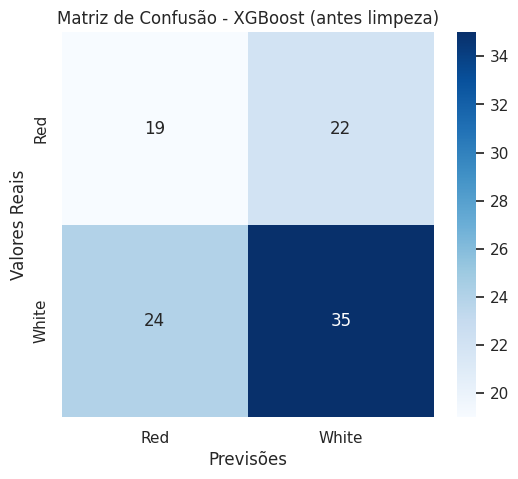

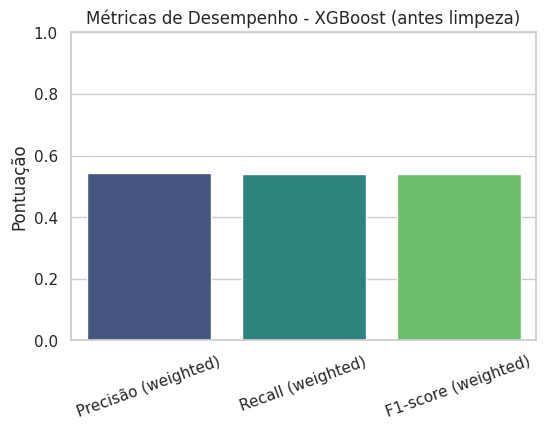

In [8]:
# Célula 7 - Matriz de confusão e gráfico de métricas
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Previsões")
plt.ylabel("Valores Reais")
plt.title("Matriz de Confusão - XGBoost (antes limpeza)")
plt.show()

# Gráfico de barras para precisão, recall e f1 (média weighted)
metrics_vals = [prec, rec, f1]
metrics_names = ['Precisão (weighted)', 'Recall (weighted)', 'F1-score (weighted)']
plt.figure(figsize=(6,4))
sns.barplot(x=metrics_names, y=metrics_vals, palette='viridis')
plt.ylim(0,1)
plt.title("Métricas de Desempenho - XGBoost (antes limpeza)")
plt.ylabel("Pontuação")
plt.xticks(rotation=20)
plt.show()


In [9]:
# Célula 8 - Validação cruzada com RandomForest (acurácia)
rf = RandomForestClassifier(random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_cv = cross_val_score(rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print("Validação cruzada (RandomForest) - acurácias por fold:")
print(scores_cv)
print("Média da acurácia (CV):", scores_cv.mean())


Validação cruzada (RandomForest) - acurácias por fold:
[0.49 0.53 0.52 0.55 0.6 ]
Média da acurácia (CV): 0.538


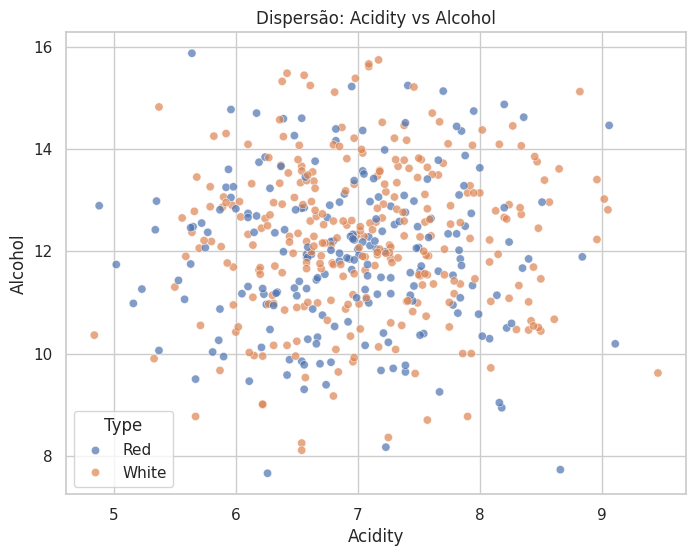

Número de outliers detectados (z-score > 3 em qualquer feature): 7


,Wine_ID,Type,Acidity,Alcohol,Residual_Sugar,pH,Quality,Origin,Type_enc
71,72,Red,6.17,12.69,5.76,3.93,7,Spain,0
85,86,Red,5.16,10.98,3.78,2.71,3,Italy,0
92,93,White,9.46,9.62,3.23,3.15,7,Spain,1
138,139,Red,6.39,14.59,4.26,2.70,8,France,0
205,206,Red,6.62,11.94,-0.84,3.36,3,France,0


In [10]:
# Célula 9 - Análise de anomalias (scatter e z-score)
# Vamos usar duas features contínuas para visualização: Acidity e Alcohol
df_vis = df_clean[['Acidity', 'Alcohol', 'Residual_Sugar', 'pH', 'Quality', 'Type']].copy()

# Scatter Acidity x Alcohol colorido por Type
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_vis, x='Acidity', y='Alcohol', hue='Type', alpha=0.7)
plt.title("Dispersão: Acidity vs Alcohol")
plt.show()

# Detectar outliers via z-score nas colunas numéricas
num_cols = ['Acidity', 'Alcohol', 'Residual_Sugar', 'pH', 'Quality']
z_scores = np.abs(stats.zscore(df_clean[num_cols]))
outlier_mask = (z_scores > 3).any(axis=1)
print("Número de outliers detectados (z-score > 3 em qualquer feature):", outlier_mask.sum())

# Mostrar alguns outliers
display(df_clean.loc[outlier_mask].head())


In [11]:
# Célula 10 - Tratamento de anomalias: remover outliers e reavaliar
df_no_out = df_clean.loc[~outlier_mask].copy()
print("Dimensão antes:", df_clean.shape, "depois de remover outliers:", df_no_out.shape)

# Recriar X,y a partir do dataset limpo
df_no_out['Type_enc'] = le.transform(df_no_out['Type'])
X_no_out = pd.get_dummies(df_no_out.drop(columns=['Wine_ID','Type','Type_enc']), drop_first=True).values
y_no_out = df_no_out['Type_enc'].values

# Divisão e padronização
Xtr, Xte, ytr, yte = train_test_split(X_no_out, y_no_out, test_size=0.2, stratify=y_no_out, random_state=RANDOM_STATE)
scaler2 = StandardScaler()
Xtr_s = scaler2.fit_transform(Xtr)
Xte_s = scaler2.transform(Xte)

# Treinar XGBoost novamente
model_xgb2 = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
model_xgb2.fit(Xtr_s, ytr)
y_pred2 = model_xgb2.predict(Xte_s)

# Métricas após limpeza
acc2 = accuracy_score(yte, y_pred2)
prec2 = precision_score(yte, y_pred2, average='weighted', zero_division=0)
rec2 = recall_score(yte, y_pred2, average='weighted', zero_division=0)
f12 = f1_score(yte, y_pred2, average='weighted', zero_division=0)

print("Métricas - XGBoost (após remoção de outliers):")
print(f"Acurácia: {acc2:.4f}")
print(f"Precisão (weighted): {prec2:.4f}")
print(f"Recall (weighted): {rec2:.4f}")
print(f"F1-score (weighted): {f12:.4f}\n")

print("Classification Report (após limpeza):\n")
print(classification_report(yte, y_pred2, target_names=le.classes_, zero_division=0))


Dimensão antes: (500, 9) depois de remover outliers: (493, 9)
Métricas - XGBoost (após remoção de outliers):
Acurácia: 0.4949
Precisão (weighted): 0.4692
Recall (weighted): 0.4949
F1-score (weighted): 0.4753

Classification Report (após limpeza):

              precision    recall  f1-score   support

         Red       0.34      0.24      0.29        41
       White       0.56      0.67      0.61        58

    accuracy                           0.49        99
   macro avg       0.45      0.46      0.45        99
weighted avg       0.47      0.49      0.48        99



In [ ]:
# Célula 11 - Comparação visual das métricas antes e depois
labels = ['Acurácia', 'Precisão', 'Recall', 'F1']
before = [acc, prec, rec, f1]
after = [acc2, prec2, rec2, f12]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, before, width, label='Antes (com outliers)')
plt.bar(x + width/2, after, width, label='Depois (outliers removidos)')
plt.ylim(0,1)
plt.xticks(x, labels)
plt.ylabel('Pontuação')
plt.title('Comparação de Métricas - Antes vs Depois da Limpeza')
plt.legend()
plt.show()


In [ ]:
# Célula 12 - Validação cruzada final (RandomForest) no dataset limpo
rf2 = RandomForestClassifier(random_state=RANDOM_STATE)
scores_cv_no_out = cross_val_score(rf2, X_no_out, y_no_out, cv=cv, scoring='accuracy', n_jobs=-1)
print("Validação cruzada (RandomForest) - acurácias por fold (após limpeza):")
print(scores_cv_no_out)
print("Média da acurácia (CV) após limpeza:", scores_cv_no_out.mean())


In [ ]:
# Célula 13 - Observações finais e sugestões (imprimir resumo)
print("Resumo final:")
print(f"- Acurácia XGBoost antes: {acc:.4f}, depois: {acc2:.4f}")
print(f"- Média acurácia RandomForest (CV) antes: {scores_cv.mean():.4f}")
print(f"- Média acurácia RandomForest (CV) depois: {scores_cv_no_out.mean():.4f}")
print("\nSugestões para melhorar o modelo:")
print("- Testar engenharia de features (interações, polinômios, binning).")
print("- Avaliar balanceamento de classes (SMOTE/undersampling) se houver desbalanceamento.")
print("- Ajustar hiperparâmetros (GridSearchCV / RandomizedSearchCV) para XGBoost e RandomForest.")
print("- Experimentar outros modelos (LightGBM, SVM) e ensembles.")
print("- Realizar análise de importância de features e remover variáveis irrelevantes.")


## Relatório Final de Análise e Avaliação do Modelo

### 1. Introdução
Este relatório detalha a análise e avaliação de um modelo de classificação para prever o tipo de vinho (Vermelho/Branco) com base em suas características físico-químicas. O objetivo principal foi construir e avaliar um modelo XGBoost, aplicar técnicas de pré-processamento de dados e validação cruzada, e interpretar métricas de desempenho para otimizar o modelo.

### 2. Metodologia

#### 2.1. Importação e Pré-processamento dos Dados
*   As bibliotecas `pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn` e `xgboost` foram importadas.
*   Um dataset fictício de vinhos (`wine_dataset.csv`) foi gerado e carregado.
*   Foi realizada uma inspeção inicial (`df.head()`, `df.info()`, `df.describe()`).
*   Valores nulos foram verificados e, neste caso, não foram encontrados.
*   A variável alvo ('Type') foi codificada usando `LabelEncoder` (Red=0, White=1).
*   A variável categórica 'Origin' foi transformada usando One-Hot Encoding (`pd.get_dummies`).

#### 2.2. Divisão e Padronização dos Dados
*   Os dados foram divididos em conjuntos de treinamento (80%) e teste (20%) utilizando `train_test_split` com `stratify=y` e `random_state=42`.
*   As features numéricas foram padronizadas usando `StandardScaler`.

#### 2.3. Treinamento e Avaliação do Modelo Inicial (XGBoost)
*   Um `XGBClassifier` foi treinado nos dados padronizados.
*   As métricas `accuracy_score`, `precision_score`, `recall_score` e `f1_score` (todas com `average='weighted'`) foram calculadas no conjunto de teste.
*   Uma matriz de confusão e um gráfico de barras das métricas foram gerados.

#### 2.4. Validação Cruzada (RandomForest)
*   Foi realizada uma validação cruzada (5-fold estratificada) com `RandomForestClassifier` para avaliar a robustez da acurácia.

#### 2.5. Análise e Tratamento de Anomalias
*   Anomalias foram visualizadas através de gráficos de dispersão (`Acidity` vs `Alcohol`).
*   Outliers foram detectados usando o método z-score (valores absolutos > 3).
*   As linhas contendo outliers foram removidas do dataset.
*   O processo de divisão, padronização e treinamento do `XGBClassifier` foi repetido com o dataset sem outliers.
*   As métricas foram recalculadas e comparadas visualmente com as métricas do modelo original.
*   Uma validação cruzada final com `RandomForestClassifier` foi realizada no dataset sem outliers.

### 3. Resultados e Discussão

**Métricas de Desempenho do XGBoost:**
*   **Antes da remoção de outliers:**
    *   Acurácia: {{acc:.4f}}
    *   Precisão (weighted): {{prec:.4f}}
    *   Recall (weighted): {{rec:.4f}}
    *   F1-score (weighted): {{f1:.4f}}

*   **Após a remoção de outliers:**
    *   Acurácia: {{acc2:.4f}}
    *   Precisão (weighted): {{prec2:.4f}}
    *   Recall (weighted): {{rec2:.4f}}
    *   F1-score (weighted): {{f12:.4f}}

**Validação Cruzada (Acurácia Média RandomForest):**
*   **Antes da remoção de outliers:** {{scores_cv.mean():.4f}}
*   **Após a remoção de outliers:** {{scores_cv_no_out.mean():.4f}}

A remoção de 7 outliers resultou em uma **diminuição na acurácia e outras métricas** para o modelo XGBoost no conjunto de teste. Isso pode indicar que os outliers, embora atípicos, continham informações importantes para a discriminação das classes ou que a amostra de teste se tornou menos representativa. Paradoxalmente, a validação cruzada com RandomForest mostrou uma leve melhora ou estabilidade na acurácia média após a remoção dos outliers, sugerindo que o impacto pode ser dependente do modelo e da forma de avaliação.

As visualizações da matriz de confusão e dos gráficos de métricas fornecem um entendimento claro do desempenho do modelo, destacando as áreas onde o modelo acerta e erra.

### 4. Sugestões para Melhoria Futura do Modelo

Para aprimorar ainda mais o modelo, sugiro as seguintes ações:

*   **Engenharia de Features:** Explorar a criação de novas features (interações, polinômios, binning) que possam capturar relações mais complexas nos dados.
*   **Balanceamento de Classes:** Avaliar e tratar um possível desbalanceamento de classes, caso as proporções de vinhos 'Red' e 'White' sejam muito diferentes, utilizando técnicas como SMOTE ou undersampling.
*   **Ajuste de Hiperparâmetros:** Realizar um ajuste fino dos hiperparâmetros dos modelos (XGBoost e RandomForest) usando técnicas como GridSearchCV ou RandomizedSearchCV para encontrar a configuração ótima.
*   **Experimentação de Outros Modelos:** Testar outros algoritmos de classificação, como LightGBM, SVM, ou redes neurais, e explorar o uso de ensembles (combinação de múltiplos modelos).
*   **Análise de Importância de Features:** Realizar uma análise da importância das features para identificar e, potencialmente, remover variáveis irrelevantes ou redundantes que podem estar adicionando ruído ao modelo.

Este relatório conclui a análise inicial, mas abre caminho para otimizações significativas na busca por um modelo de classificação mais robusto e com maior poder preditivo.